# PEER+TEXT on held-out set E — gold-free NL→FOL faithfulness scoring (demo)

This notebook is the driver script `method.py` from the experiment **"Peer agreement plus text checks, held-out test"**, split into cells, with notes between them.

**The research question.** You have a sentence and a candidate first-order-logic (FOL) formalisation, and **no gold formula**. Can a cheap score predict whether the candidate is *faithful* to the sentence?

**The method (PEER+TEXT).** The method has two parts:
* **PEER** is graded cross-family consensus. Formalisations of the same sentence from *other* model families ("peers") are aligned into the candidate's vocabulary. The candidate is split into claim units. Each unit is then checked for entailment against the peers with a finite-model refuter and z3. This yields `support`, `coverage` and `g_score`, plus per-unit error codes (ADD / DROP / …).
* **TEXT** is a set of solver-exact text checks from iteration 1. `l2_bow` does bag-of-words content accounting. `l3_z3` compares a text-only questionnaire against the z3 role profile.
* **Fusion.** A logistic regression combines the features `ALIGN:g_score`, `c_score_align`, `l2_bow` and `l3_z3`. It was fitted on the iteration-1 screen and then **frozen** in a pre-registration (sha256 `b9f28b1b…`) *before* the held-out set E was scored, once.

**Held-out results on E** (8,507 candidate rows, 700 sentences, 13 systems; label regime R_AB = tiers A+B, 1,822 errors vs 864 correct):

| score | AUROC |
|---|---|
| **PEER+TEXT fusion** | **.790** [.75, .82] |
| iteration-1 consensus `c_score_align` | .782 |
| TEXT only | .693 |
| local Qwen3-8B disguised judge | .712 |

The fusion beats the local judge by +.078 [.043, .112], but it does **not** beat `c_score_align` alone.

**What this notebook runs.** The full pipeline has six stages that need hours of solver work, the OpenRouter API and a GPU. Those stages are `views`, `api`, `local`, `screen`, `score` and `analyse`, each a separate script under `src/` in the original repo. The notebook keeps the driver code for them but does not run them. It **runs the last stage, `outputs` (`build_outputs()`)**, on a curated 100-row subset of E. That subset holds the real per-item scores, labels, blind view and frozen prereg. The final cells then:
* re-derive the frozen fusion score from its three input features;
* compute per-metric AUROCs on the demo rows;
* plot them against the full-E headline numbers.

## Setup
Install the packages. `loguru` is the only package the original script needs that Colab lacks. The core scientific stack is installed at Colab's pinned versions only when the notebook runs outside Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


Imports. The first block is `method.py`'s original import block, unchanged. The second block adds what the notebook needs for the re-derivation and plotting cells.

In [2]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions (results / visualisation cells only) ---
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

### Data loading
`mini_demo_data.json` is fetched from the paper's GitHub repo, with a local fallback. It is a 100-row curated subset of E: 84 rows labelled ERROR/CORRECT in tiers A/B (44 ERROR / 40 CORRECT), spread over all 4 complexity strata and 13 systems, plus 16 other rows (tier-C labels, UNPARSEABLE, CONTESTED, UNRESOLVED) that show how coverage is handled. It also contains the frozen pre-registration and the full-E headline tables that `build_outputs()` reads.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/main/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "description"})

{'per_item_E': 100, 'E_labels': 100, 'E_blind': 100, 'analysis': 2, 'prereg': 4, 'prereg_sha256': 'b9f28b1bf6bfd29c99d03eb128f2ad64fd2d14d40356a4c5f1fdd16a415838ab  prereg.json  2026-09-23T18:23:50.564681+00:00\n', 'p_tests': 6}


## Config
All tunable parameters of the demo are set here.

`method.py` itself has only one parameter: the stage to run. It is normally read from `sys.argv[1]` and defaults to `"all"`.
* `STAGE = "outputs"` runs the only stage that does not need the `src/` scripts, the API key or a GPU.
* `"all"` is the original default. It re-runs the whole pipeline and needs the full original repository.

In [5]:
# method.py: stage = sys.argv[1] if given, else "all" (original default). Only "outputs" is runnable in this notebook.
STAGE = "outputs"          # original: "all"
N_ROWS = 100               # rows of the curated E subset to use (max 100 in mini_demo_data.json; full E = 8,507 rows)
N_BOOT = 1000              # bootstrap resamples for the demo AUROC CIs (full analysis used sentence-clustered bootstrap)
SEED = 0

## Setup of the pipeline root
This is the module-level setup of `method.py`, unchanged: the root directory, the interpreter paths of the two virtual environments (`.venv` for CPU, `.venv_gpu` for the local judge) and loguru sinks to stdout and `logs/method.log`.

Two minimal notebook fixes:
* `__file__` does not exist in a notebook, so `ROOT` is the current directory.
* `logs/` is created first.

In [6]:
ROOT = Path(".").resolve()          # original: Path(__file__).resolve().parent
PY = str(ROOT / ".venv" / "bin" / "python")
PY_GPU = str(ROOT / ".venv_gpu" / "bin" / "python")

(ROOT / "logs").mkdir(exist_ok=True)  # notebook fix: the original repo already has logs/
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

2

### Stage inputs from the loaded data
In the original repo, `build_outputs()` reads six files written by the earlier stages:

| file | written by |
|---|---|
| `results/per_item_E.jsonl` | `score_E.py assemble`: every metric's score per row |
| `data/E_labels.jsonl` | `data_views.py`: label view, joined only after scoring |
| `data/E_blind.jsonl` | `data_views.py`: blind view (text + candidate FOL) |
| `results/analysis.json` | `analyse_E.py` |
| `results/prereg.json`, `results/prereg.sha256` | `screen_fit.py freeze`: the frozen pre-registration |
| `results/p_tests.json` | analysis verdicts |

This cell writes the first `N_ROWS` rows of `data` into that same layout. The original code can then run with no changes to its file reads.

In [7]:
(ROOT / "results").mkdir(exist_ok=True)
(ROOT / "data").mkdir(exist_ok=True)

def _wjl(p, rows):
    p.write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))

_wjl(ROOT / "results" / "per_item_E.jsonl", data["per_item_E"][:N_ROWS])
_wjl(ROOT / "data" / "E_labels.jsonl", data["E_labels"][:N_ROWS])
_wjl(ROOT / "data" / "E_blind.jsonl", data["E_blind"][:N_ROWS])
(ROOT / "results" / "analysis.json").write_text(json.dumps(data["analysis"]))
(ROOT / "results" / "prereg.json").write_text(json.dumps(data["prereg"]))
(ROOT / "results" / "prereg.sha256").write_text(data["prereg_sha256"])
(ROOT / "results" / "p_tests.json").write_text(json.dumps(data["p_tests"]))
print("staged", N_ROWS, "rows; prereg sha256:", data["prereg_sha256"].split()[0][:8])

staged 100 rows; prereg sha256: b9f28b1b


## Helpers
These are the original small helpers:
* `sh` runs one pipeline stage as a subprocess and fails loudly.
* `jl` reads a JSONL file.
* `s` formats a score as a string, with `"NA"` for missing and 6 decimals for floats.

In [8]:
def sh(args: list[str]) -> None:
    logger.info("$ " + " ".join(args))
    r = subprocess.run(args, cwd=ROOT)
    if r.returncode != 0:
        raise RuntimeError(f"stage failed ({r.returncode}): {' '.join(args)}")


def jl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()] if p.exists() else []


def s(x) -> str:
    if x is None:
        return "NA"
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

## `build_outputs()`: join scores with labels and write `method_out.json`
This is the `outputs` stage, unchanged. For every row of E it joins three views:
* the **blind view**: sentence, candidate FOL, system, prompt variant;
* the **scores** of every metric, as `predict_*`. All are oriented so that *higher = more likely an error*;
* the **label view**, joined only *after* scoring, as `output` plus the label tier, repair/error ops and so on.

Some of the `predict_*` scores:
* `predict_peer_text` is the frozen fusion (the method), with `predict_peer_text_flag` as its thresholded flag.
* `predict_peer` and `predict_text` are the two halves of the fusion.
* `predict_c_score_align` is iteration 1's binary consensus. `predict_nf_*` is the name-free consensus.
* `predict_l2_bow`, `predict_l3`, `predict_l1_any` and `predict_l2_role` are the text checks.
* `predict_judge_*` are the LLM judges: flash-lite and local Qwen3-8B, each with the original and the disguised prompt.

The metadata carries the frozen fusion, the headline AUROC tables of the full E analysis and the P1–P4 verdicts.

In [9]:
def build_outputs() -> None:
    """method_out.json in the exp_gen_sol_out schema: one example per E row (input = blind-view JSON, output = the E
    final label joined AFTER the analysis), predict_* = every metric's score (higher = more likely an error)."""
    items = jl(ROOT / "results" / "per_item_E.jsonl")
    labels = {r["row_key"]: r for r in jl(ROOT / "data" / "E_labels.jsonl")}
    blind = {r["row_key"]: r for r in jl(ROOT / "data" / "E_blind.jsonl")}
    analysis = json.loads((ROOT / "results" / "analysis.json").read_text())
    pre = json.loads((ROOT / "results" / "prereg.json").read_text())
    ex = []
    for r in items:
        b = blind[r["row_key"]]
        L = labels[r["row_key"]]
        inp = {"text": b["text"], "candidate_fol": b["candidate_fol"], "system": b["system"], "prompt_variant": b["prompt_variant"],
               "row_key": r["row_key"], "item_id": b["item_id"], "sentence_id": b["sentence_id"]}
        e = {"input": json.dumps(inp, ensure_ascii=False), "output": L["final_label"],
             "predict_peer_text": s(r.get("p_peer_text")), "predict_peer_text_flag": s(r.get("flag")),
             "predict_peer": s(r.get("peer_only")), "predict_text": s(r.get("p_text")),
             "predict_g_score": s(r.get("g_score")), "predict_c_score_nf": s(r.get("c_score_nf")),
             "predict_c_score_align": s(r.get("c_score_align")), "predict_nf_g_score": s(r.get("nf_g_score")),
             "predict_nf_c_score": s(r.get("nf_c_score")), "predict_l2_bow": s(r.get("l2_bow")), "predict_l3": s(r.get("l3_z3")),
             "predict_l1_any": s(r.get("l1_any")), "predict_l2_role": s(r.get("l2_role")),
             "predict_judge_cheap_disg": s(r.get("judge_cheap_disg")), "predict_judge_cheap_orig": s(r.get("judge_cheap_orig")),
             "predict_judge_local_qwen8b_disg": s(r.get("judge_local_qwen8b_disg")),
             "predict_judge_local_qwen8b_orig": s(r.get("judge_local_qwen8b_orig")),
             "metadata_row_key": r["row_key"], "metadata_item_id": r["item_id"], "metadata_sentence_id": r["sentence_id"],
             "metadata_system": r["system"], "metadata_system_class": r["system_class"], "metadata_family_vendor": r["family_vendor"],
             "metadata_stratum": r["stratum"], "metadata_strata": r["strata"], "metadata_fold_E": r["fold_E"],
             "metadata_label_tier": L["label_tier"], "metadata_repair_ops": L["repair_ops"], "metadata_error_ops": L["error_ops"],
             "metadata_reading_choice": L["reading_choice"], "metadata_coverage_status": r["coverage_status"],
             "metadata_unit_codes": [c["code"] + ":" + c.get("unit", "")[:120] for c in (r.get("unit_codes") or [])][:12],
             "metadata_top_code": r.get("top_code"), "metadata_fired_signal": r.get("fired_signal"),
             "metadata_model_used": r.get("model_used"), "metadata_n_unknown": r.get("n_unknown"),
             "metadata_n_peers_used": r.get("n_peers_used"), "metadata_peer_unavailable": r.get("peer_unavailable"),
             "metadata_support": r.get("support"), "metadata_coverage": r.get("coverage"),
             "metadata_medoid_ops": r.get("medoid_ops"), "metadata_judge_local_type": r.get("judge_local_qwen8b_disg_type"),
             "metadata_cost_usd": (r.get("cost_usd_peer_text") or 0.0), "metadata_judge_cost_usd": r.get("judge_cost_usd"),
             "metadata_secs": (r.get("secs_pairs") or 0.0) + (r.get("secs_text") or 0.0),
             "metadata_prereg_sha256": r["prereg_sha256"]}
        ex.append(e)
    heads = {k: {kk: vv for kk, vv in v.items() if kk in ("n", "n_error", "n_correct", "metrics")} for k, v in analysis["a_tables"].items()}
    out = {"metadata": {
        "method_name": "PEER+TEXT (graded cross-family consensus fused with solver-exact text checks), frozen on the screen, scored once on E",
        "prereg_sha256": (ROOT / "results" / "prereg.sha256").read_text().split()[0],
        "peer_variant": pre["variant"], "F1_failed_on_screen": pre["selection_evidence"]["F1_failed"],
        "fusion": pre["frozen"]["fusion"], "text_only": pre["frozen"]["text_only"],
        "orientation": "every predict_* is oriented so that higher = more likely an error; NA = not available",
        "headline_auroc_tables": heads, "criteria": analysis["criteria"],
        "p_tests": json.loads((ROOT / "results" / "p_tests.json").read_text()),
        "workspace": str(ROOT)},
        "datasets": [{"dataset": "E_heldout_candidates", "examples": ex}]}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"method_out.json: {len(ex)} examples, {(ROOT / 'method_out.json').stat().st_size / 1e6:.1f} MB")

## `main()`: the stage driver
Each stage is resumable and cached. In the original repo, `uv run method.py all` re-runs whatever is missing:

| stage | script | what it does |
|---|---|---|
| `views` | `src/data_views.py` | builds the blind view of E through an allowlist, the label view and the API row order |
| `api` | `src/run_api_E.py` | L3 questionnaires and the flash-lite judges on E; needs the shared key |
| `local` | `src/local_judge_E.py` | local Qwen3-8B judge; needs a GPU |
| `screen` | `src/screen_fit.py compute\|fit\|freeze` | screen features, variant selection, fusion fit, prereg freeze |
| `score` | `src/score_E.py run --stage mini\|100\|all` then `assemble` | peer/text scoring of E, done in stages |
| `analyse` | `src/analyse_E.py` | the only label join, guarded by the prereg hash and file mtimes |
| `outputs` | `build_outputs()` | writes `method_out.json` |

The only change: `stage` comes from the config cell (`STAGE`), not `sys.argv`. With `STAGE = "outputs"`, every `sh(...)` stage is skipped.

In [10]:
@logger.catch(reraise=True)
def main():
    stage = STAGE  # original: sys.argv[1] if len(sys.argv) > 1 else "all"
    if stage in ("views", "all"):
        sh([PY, "src/data_views.py"])
    if stage in ("api", "all"):
        sh([PY, "src/run_api_E.py"])
    if stage in ("local", "all") and Path(PY_GPU).exists():
        sh([PY_GPU, "src/local_judge_E.py"])
    if stage in ("screen", "all"):
        if not (ROOT / "results" / "prereg.json").exists():
            sh([PY, "src/screen_fit.py", "compute"])
            sh([PY, "src/screen_fit.py", "fit"])
            sh([PY, "src/screen_fit.py", "freeze"])
    if stage in ("score", "all"):
        for st in ("mini", "100", "all"):
            sh([PY, "src/score_E.py", "run", "--stage", st])
        sh([PY, "src/score_E.py", "assemble"])
    if stage in ("analyse", "all"):
        sh([PY, "src/analyse_E.py"])
    if stage in ("outputs", "all"):
        build_outputs()

In [11]:
_t0 = time.time()
main()
print(f"main() finished in {time.time() - _t0:.2f}s")

18:03:14|INFO   |method_out.json: 100 examples, 0.3 MB


main() finished in 0.08s


## Re-derive the frozen fusion from its features
The fused score `p_peer_text` comes from `fused_score()` in the reusable library `src/peer_text.py`. The three functions below are copied from that file verbatim.

They are applied to each row's four stored features:
* `ALIGN:g_score`, the graded peer consensus in the candidate's vocabulary;
* `c_score_align`, iteration 1's binary aligned consensus;
* `l2_bow`, text content accounting;
* `l3_z3`, the text questionnaire compared with the z3 role profile.

The rules for special rows:
* An unparseable candidate gets `p_error = 1.0`.
* If the peer feature is missing, the frozen TEXT-only model is used instead.

The recomputed score should match the stored `p_peer_text` to floating-point precision.

In [12]:
# --- verbatim from src/peer_text.py (fusion section) ---
def _z(x, mu, sd):
    return 0.0 if x is None else (x - mu) / (sd if sd > 0 else 1.0)


def apply_logistic(model: dict, feats: dict) -> float:
    """model = {'features', 'mean', 'sd', 'coef', 'intercept'}; missing feature -> z = 0."""
    s = model["intercept"]
    for f, m, sd, c in zip(model["features"], model["mean"], model["sd"], model["coef"]):
        s += c * _z(feats.get(f), m, sd)
    return 1 / (1 + math.exp(-s))


def fused_score(frozen: dict, feats: dict) -> dict:
    """Frozen PEER+TEXT fusion. Unparseable -> p_error 1.0. peer_unavailable -> frozen TEXT-only model (pre-registered).
    fired_signal = argmax standardized contribution (PEER = g/c_score_nf features, TEXT = l2_bow/l3)."""
    if feats.get("coverage_status") == "UNPARSEABLE":
        return {"p_error": 1.0, "flag": 1, "fired_signal": "UNPARSEABLE", "model_used": "none"}
    main = frozen["fusion"]
    use = main
    if feats.get("peer_unavailable") or feats.get(main["features"][0]) is None:
        use = frozen["text_only"]
    p = apply_logistic(use, feats)
    contrib = {f: c * _z(feats.get(f), m, sd) for f, m, sd, c in zip(use["features"], use["mean"], use["sd"], use["coef"])}
    top = max(contrib, key=contrib.get) if contrib else None
    sig = "PEER" if top in ("g_score", "c_score_nf", "c_score_align") else ("TEXT" if top else None)
    thr = main["threshold"] if use is main else frozen["text_only"]["threshold"]
    return {"p_error": p, "flag": int(p >= thr), "fired_signal": sig, "model_used": "fusion" if use is main else "text_only"}

In [13]:
frozen = data["prereg"]["frozen"]
fz = frozen["fusion"]
print("frozen fusion features:", fz["features"], "coef:", np.round(fz["coef"], 3).tolist(),
      "intercept:", round(fz["intercept"], 3), "threshold:", round(fz["threshold"], 3))

diffs, flag_agree = [], 0
for r in data["per_item_E"][:N_ROWS]:
    # per_item_E stores the ALIGN-variant peer features under un-prefixed names; map them back to the prereg feature names
    feats = {f"{r['variant']}:g_score": r["g_score"], f"{r['variant']}:c_score_nf": r["c_score_nf"],
             "c_score_align": r["c_score_align"], "l2_bow": r["l2_bow"], "l3_z3": r["l3_z3"],
             "peer_unavailable": r["peer_unavailable"], "coverage_status": r["coverage_status"]}
    fs = fused_score(frozen, feats)
    diffs.append(abs(fs["p_error"] - r["p_peer_text"]))
    flag_agree += int(fs["flag"] == r["flag"])
print(f"re-derived p_peer_text vs stored: max |diff| = {max(diffs):.2e} over {len(diffs)} rows; flags agree {flag_agree}/{len(diffs)}")

frozen fusion features: ['ALIGN:g_score', 'c_score_align', 'l2_bow', 'l3_z3'] coef: [-0.116, 1.746, 3.087, 0.845] intercept: 2.614 threshold: 0.69
re-derived p_peer_text vs stored: max |diff| = 0.00e+00 over 100 rows; flags agree 100/100


## Results
Load the `method_out.json` that `main()` just wrote. The label regime of the headline is R_AB: rows whose final label is ERROR or CORRECT with label tier A or B. On those demo rows, compute each metric's AUROC for predicting ERROR, with a percentile bootstrap CI. Then compare it to the **full-E** AUROC stored in the headline table.

With only 84 labelled rows, the demo AUROCs have wide CIs. They show that the pipeline and the orientation work; they do not reproduce the headline.

In [14]:
mo = json.loads((ROOT / "method_out.json").read_text())
ex = mo["datasets"][0]["examples"]
lab = [e for e in ex if e["output"] in ("ERROR", "CORRECT") and e["metadata_label_tier"] in ("A", "B")]
y_all = np.array([int(e["output"] == "ERROR") for e in lab])
print(f"method_out.json: {len(ex)} rows; R_AB-labelled: {len(lab)} ({y_all.sum()} ERROR / {len(y_all) - y_all.sum()} CORRECT)")

# predict_* column -> key in the full-E headline table (analysis a_tables['R_AB pooled'])
METRICS = [("predict_peer_text", "p_peer_text", "PEER+TEXT (fusion)"),
           ("predict_c_score_align", "c_score_align", "c_score_align (iter-1)"),
           ("predict_peer", "peer_only", "PEER only (g_score)"),
           ("predict_nf_c_score", "nf_c_score", "NF-anchored c_score"),
           ("predict_text", "p_text", "TEXT only"),
           ("predict_l2_bow", "l2_bow", "L2-bow"),
           ("predict_l3", "l3_z3", "L3 (z3)"),
           ("predict_l2_role", "l2_role", "L2-role"),
           ("predict_l1_any", "l1_any", "L1 lint"),
           ("predict_judge_local_qwen8b_disg", "judge_local_qwen8b_disg", "Qwen3-8B judge (disg.)")]
head = mo["metadata"]["headline_auroc_tables"]["R_AB pooled"]
# the judge's full-E AUROC lives in the paired judge table of the analysis (same R_AB rows; not copied into method_out.json)
full_judge = {"judge_local_qwen8b_disg":
              data["analysis"]["a_tables"]["R_AB pooled"]["vs_judge_local_qwen8b_disg"]["metrics"]["judge_local_qwen8b_disg"]["auroc"]}
rng = np.random.default_rng(SEED)
rows = []
for col, key, name in METRICS:
    v = [(float(e[col]), yy) for e, yy in zip(lab, y_all) if e[col] != "NA"]
    x = np.array([a for a, _ in v]); y = np.array([b for _, b in v])
    auc = roc_auc_score(y, x) if 0 < y.sum() < len(y) else float("nan")
    boots = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(y), len(y))
        if 0 < y[idx].sum() < len(idx):
            boots.append(roc_auc_score(y[idx], x[idx]))
    lo, hi = (np.percentile(boots, [2.5, 97.5]) if boots else (float("nan"), float("nan")))
    full = head["metrics"].get(key, {}).get("auroc", full_judge.get(key))
    rows.append((name, len(y), auc, lo, hi, full))

print(f"\n{'metric':<26}{'n':>4}{'demo AUROC':>12}{'95% CI':>16}{'full-E AUROC':>14}")
for name, n, auc, lo, hi, full in rows:
    print(f"{name:<26}{n:>4}{auc:>12.3f}{f'[{lo:.2f},{hi:.2f}]':>16}{(f'{full:.3f}' if full is not None else 'NA'):>14}")
print(f"\nfull E R_AB pooled: n={head['n']} ({head['n_error']} ERROR / {head['n_correct']} CORRECT)")
print("pre-registered prediction verdicts:", {k: v for k, v in mo["metadata"]["p_tests"].items() if k != "criteria"})

method_out.json: 100 rows; R_AB-labelled: 84 (44 ERROR / 40 CORRECT)



metric                       n  demo AUROC          95% CI  full-E AUROC
PEER+TEXT (fusion)          84       0.643     [0.52,0.76]         0.790
c_score_align (iter-1)      83       0.715     [0.61,0.82]         0.782
PEER only (g_score)         84       0.693     [0.58,0.80]         0.748
NF-anchored c_score         83       0.703     [0.59,0.81]         0.743
TEXT only                   84       0.563     [0.43,0.69]         0.693
L2-bow                      84       0.575     [0.46,0.69]         0.734
L3 (z3)                     84       0.510     [0.39,0.63]         0.579
L2-role                     84       0.571     [0.48,0.66]         0.572
L1 lint                     84       0.544     [0.50,0.60]         0.546
Qwen3-8B judge (disg.)      83       0.603     [0.49,0.72]         0.712

full E R_AB pooled: n=2686 (1822 ERROR / 864 CORRECT)
pre-registered prediction verdicts: {'P1_R_AB': 'INCONCLUSIVE', 'P1_R_A': 'INCONCLUSIVE', 'P2': 'REFUTED', 'P3': 'INCONCLUSIVE', 'P4': 'REFUT

### Plot: demo AUROC vs full-E AUROC, and the fused score by label
The left panel shows each metric's AUROC on the demo rows, with bootstrap CIs, next to the full-E headline value (hollow marker). The right panel shows the distribution of the fused PEER+TEXT error probability for ERROR vs CORRECT rows, with the frozen flag threshold.

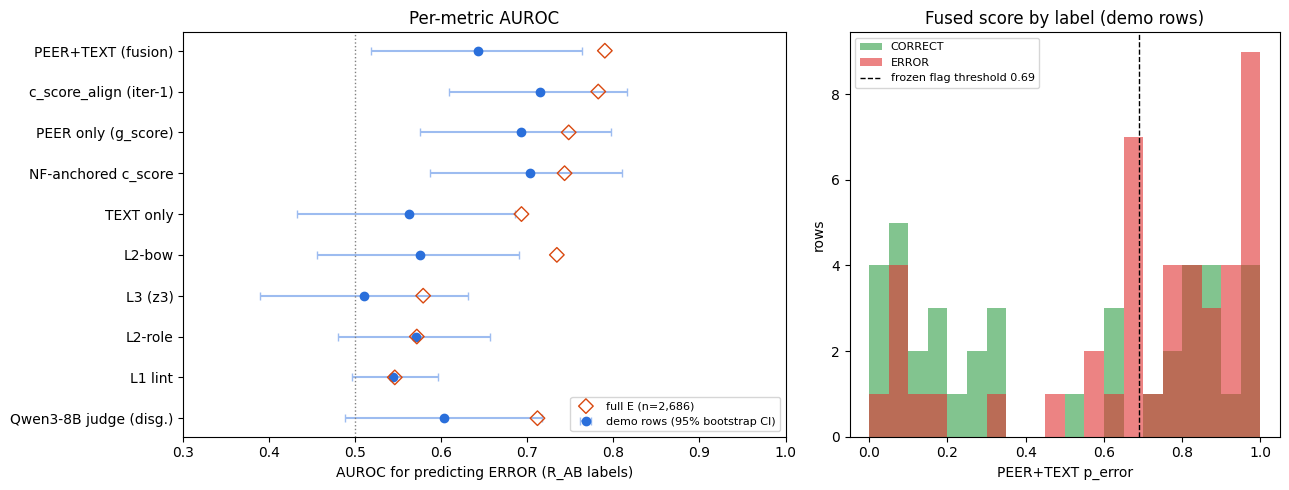

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
names = [r[0] for r in rows][::-1]
yy = np.arange(len(names))
demo = np.array([r[2] for r in rows][::-1]); lo = np.array([r[3] for r in rows][::-1]); hi = np.array([r[4] for r in rows][::-1])
full = [r[5] for r in rows][::-1]
ax.errorbar(demo, yy, xerr=[demo - lo, hi - demo], fmt="o", color="#2a6fdb", ecolor="#9dbcf0", capsize=3, label="demo rows (95% bootstrap CI)")
ax.scatter([f if f is not None else np.nan for f in full], yy, marker="D", facecolors="none", edgecolors="#d9480f", s=55, zorder=3, label="full E (n=2,686)")
ax.axvline(0.5, color="grey", ls=":", lw=1)
ax.set_yticks(yy); ax.set_yticklabels(names); ax.set_xlim(0.3, 1.0)
ax.set_xlabel("AUROC for predicting ERROR (R_AB labels)"); ax.set_title("Per-metric AUROC")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
p = np.array([float(e["predict_peer_text"]) for e in lab])
bins = np.linspace(0, 1, 21)
ax.hist(p[y_all == 0], bins=bins, alpha=0.6, color="#2f9e44", label="CORRECT")
ax.hist(p[y_all == 1], bins=bins, alpha=0.6, color="#e03131", label="ERROR")
ax.axvline(fz["threshold"], color="k", ls="--", lw=1, label=f"frozen flag threshold {fz['threshold']:.2f}")
ax.set_xlabel("PEER+TEXT p_error"); ax.set_ylabel("rows"); ax.set_title("Fused score by label (demo rows)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### A few scored rows
Each row shows the sentence, the candidate FOL and its label. It then shows the fused score, which signal fired (PEER or TEXT) and the first unit-level error codes from the peer check.

In [16]:
for e in [x for x in lab if x["output"] == "ERROR"][:3] + [x for x in lab if x["output"] == "CORRECT"][:2]:
    inp = json.loads(e["input"])
    print(f"[{e['output']}] {inp['system']}  stratum={e['metadata_stratum']}  p_peer_text={float(e['predict_peer_text']):.3f} "
          f"flag={e['predict_peer_text_flag']}  fired={e['metadata_fired_signal']}  error_ops={e['metadata_error_ops']}")
    print("  text:", inp["text"][:200])
    print("  fol :", inp["candidate_fol"][:200])
    print("  unit codes:", e["metadata_unit_codes"][:3])
    print()

[ERROR] G9:cohere/command-r7b-12-2024  stratum=CTRL  p_peer_text=0.052 flag=0  fired=TEXT  error_ops=['ADD', 'DROP']
  text: All of Emily's friends who are award-winning novelists publish journals.
  fol : ∀x (Friend(x, emily) ∧ AwardWinningNovelist(x) → Publishes(x, journals))
  unit codes: []

[ERROR] malls_gpt4_gold  stratum=L25  p_peer_text=0.981 flag=1  fired=PEER  error_ops=['COMPOUND', 'ADD', 'DROP', 'RESTR', 'UNGLUE']
  text: A river is a natural watercourse flowing towards an ocean, sea, or lake, a canal is a man-made waterway used for transportation or irrigation, and a stream is a smaller, natural watercourse.
  fol : ∀x ∀y ∀z (River(x) ∧ Canal(y) ∧ Stream(z) → (NaturalWatercourse(x) ∧ FlowsTo(x) ∧ ManMadeWaterway(y) ∧ UsedFor(y) ∧ SmallerNaturalWatercourse(z)))
  unit codes: ['QUANT:∀v0 (∀v1 (∀v2 ((((River(v0) ∧ Canal(v1)) ∧ Stream(v2)) → NaturalWatercourse(v0)))))', 'ADD:∀v0 (∀v1 (∀v2 ((((River(v0) ∧ Canal(v1)) ∧ Stream(v2)) → FlowsTo(v0)))))', 'QUANT:∀v0 (∀v1 (∀v2 ((((Riv